# 2. Feature Extraction

## Summary
This notebook transforms the preprocessed audio segments into fixed-size feature tensors ready for model training.

### Pipeline
1. Load the final preprocessed metadata CSV (output of notebook 01);
2. Extract **MFCC** features (40 coefficients, 0–8 kHz) following the DronePrint paper;
3. Apply **peak normalisation** per frame and **L2 feature-vector rescaling**;
4. Visualise MFCC matrices for drone vs. non-drone samples;
5. Persist feature arrays and labels as `.npy` files.

### Key design decisions (aligned with DronePrint)
- Sample rate: **44 100 Hz**
- Frame size: **200 ms** (8 820 samples), **no overlap**
- MFCC: **40 coefficients**, Mel filterbanks spanning **0–8 kHz**
- Feature matrix shape per segment: **(T, 40)** where T = number of frames
- Fixed time context for CNN input: **10 frames → (10, 40, 1)**


### Imports

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Audio / MFCC constants (DronePrint §4) ───
SAMPLE_RATE   = 44_100
FRAME_MS      = 200          # ms per frame
FRAME_SAMPLES = int(FRAME_MS * SAMPLE_RATE / 1000)  # 8 820
N_MFCC        = 40
FMAX          = 8_000        # Hz  (DronePrint focuses on 0-8 kHz)
N_FFT         = 2048
HOP_LENGTH    = FRAME_SAMPLES   # no overlap between frames
N_FRAMES      = 10          # context window fed to CNN (≈ 2 s at 200 ms/frame)

print(f"Frame duration : {FRAME_MS} ms  ({FRAME_SAMPLES} samples)")
print(f"Context window : {N_FRAMES} frames = {N_FRAMES * FRAME_MS / 1000:.1f} s")
print(f"MFCC shape     : ({N_FRAMES}, {N_MFCC}, 1) per sample")


Frame duration : 200 ms  (8820 samples)
Context window : 10 frames = 2.0 s
MFCC shape     : (10, 40, 1) per sample


## 2.1  Load metadata

In [2]:
META_PATH = "final_preprocessed_metadata.csv"   # written by notebook 01

df = pd.read_csv(META_PATH)
print(f"Total segments : {len(df)}")
print(df["label"].value_counts())
df.head()


Total segments : 2082
label
non_drone    1350
drone         732
Name: count, dtype: int64


,file_path,label
0,./data/normalized_segments\DS1_Bebop2_drone_Be...,drone
1,./data/normalized_segments\DS1_Bebop2_drone_Be...,drone
2,./data/normalized_segments\DS1_Bebop2_drone_Be...,drone
3,./data/normalized_segments\DS1_Bebop2_drone_Be...,drone
4,./data/normalized_segments\DS1_Bebop2_drone_Be...,drone


## 2.2  MFCC extraction helpers

In [3]:
def peak_normalize_frame(frame: np.ndarray) -> np.ndarray:
    """Time-domain peak normalisation per 200 ms frame (DronePrint §4.2)."""
    peak = np.max(np.abs(frame))
    return frame / peak if peak > 0.0 else frame


def l2_normalize_vector(vec: np.ndarray) -> np.ndarray:
    """Feature-vector L2 rescaling (DronePrint §4.4)."""
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0.0 else vec


def extract_mfcc_matrix(file_path: str) -> np.ndarray | None:
    """
    Load one audio segment and return a (T, N_MFCC) MFCC matrix.

    Processing order:
        1. Load at 44 100 Hz
        2. Split into 200 ms non-overlapping frames
        3. Peak-normalise each frame
        4. Compute 40 MFCCs (0-8 kHz Mel scale)
        5. L2-normalise each MFCC vector
    Returns None if the file is too short.
    """
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
    except Exception:
        return None

    n_frames = len(y) // FRAME_SAMPLES
    if n_frames == 0:
        return None

    mfcc_rows = []
    for i in range(n_frames):
        frame = y[i * FRAME_SAMPLES : (i + 1) * FRAME_SAMPLES]
        frame = peak_normalize_frame(frame)

        # librosa MFCC on a single frame
        mfcc = librosa.feature.mfcc(
            y=frame, sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=len(frame) + 1,   # single column
            fmax=FMAX,
        )                                # shape: (N_MFCC, 1)
        mfcc_vec = mfcc[:, 0]            # shape: (N_MFCC,)
        mfcc_vec = l2_normalize_vector(mfcc_vec)
        mfcc_rows.append(mfcc_vec)

    return np.array(mfcc_rows)           # (n_frames, N_MFCC)


def sliding_windows(matrix: np.ndarray, n_frames: int = N_FRAMES) -> np.ndarray:
    """
    Cut a (T, 40) MFCC matrix into non-overlapping (n_frames, 40) windows.
    Returns array of shape (n_windows, n_frames, 40).
    """
    T = matrix.shape[0]
    n_windows = T // n_frames
    if n_windows == 0:
        return np.empty((0, n_frames, N_MFCC))
    windows = []
    for i in range(n_windows):
        windows.append(matrix[i * n_frames : (i + 1) * n_frames])
    return np.array(windows)             # (n_windows, 10, 40)


print("Helper functions defined.")


Helper functions defined.


## 2.3  Visualise MFCC features

In [4]:
# ── Pick one drone and one non-drone sample ──────────────────────────────────
drone_file    = df[df["label"] == "drone"].iloc[0]["file_path"]
nondrone_file = df[df["label"] == "non_drone"].iloc[0]["file_path"]

drone_mfcc    = extract_mfcc_matrix(drone_file)
nondrone_mfcc = extract_mfcc_matrix(nondrone_file)

print(f"Drone MFCC matrix   : {drone_mfcc.shape}   (frames × coefficients)")
print(f"Non-drone MFCC matrix: {nondrone_mfcc.shape}")


Drone MFCC matrix   : (10, 40)   (frames × coefficients)
Non-drone MFCC matrix: (10, 40)


FileNotFoundError: [Errno 2] No such file or directory: 'plots/mfcc_matrices_comparison.png'

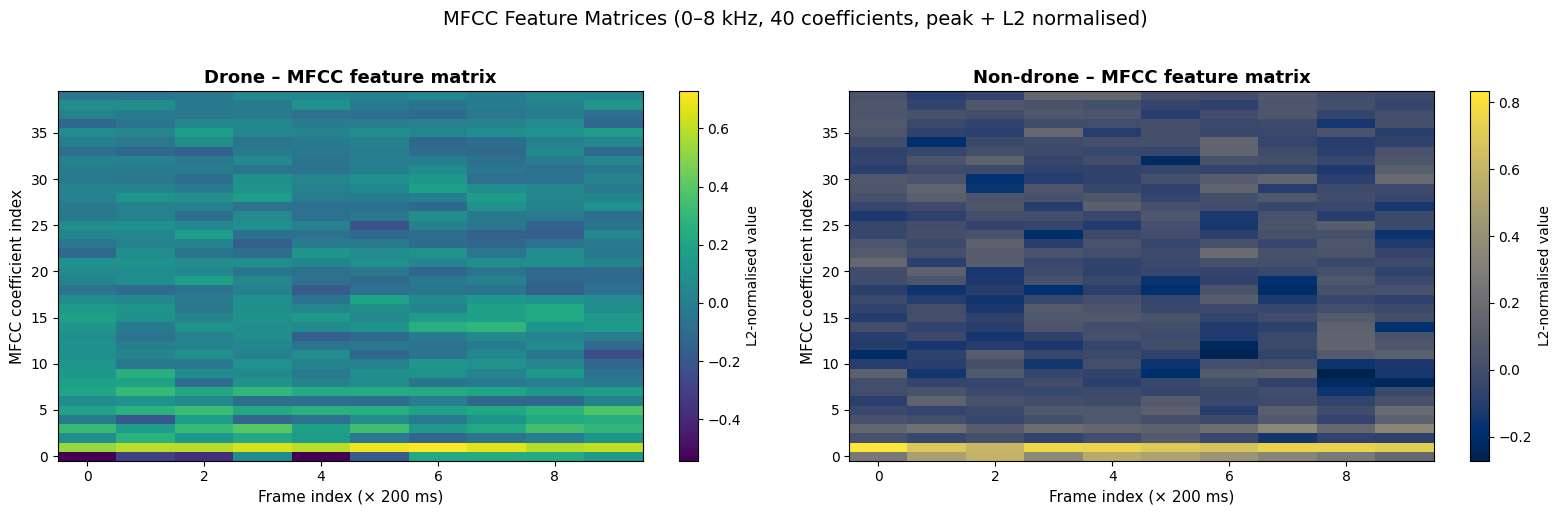

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, mfcc, title, cmap in zip(
        axes,
        [drone_mfcc, nondrone_mfcc],
        ["Drone – MFCC feature matrix", "Non-drone – MFCC feature matrix"],
        ["viridis", "cividis"]):
    img = ax.imshow(mfcc.T, aspect="auto", origin="lower", cmap=cmap)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Frame index (× 200 ms)", fontsize=11)
    ax.set_ylabel("MFCC coefficient index", fontsize=11)
    plt.colorbar(img, ax=ax, label="L2-normalised value")

plt.suptitle("MFCC Feature Matrices (0–8 kHz, 40 coefficients, peak + L2 normalised)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plots/mfcc_matrices_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'plots/mfcc_mean_profile.png'

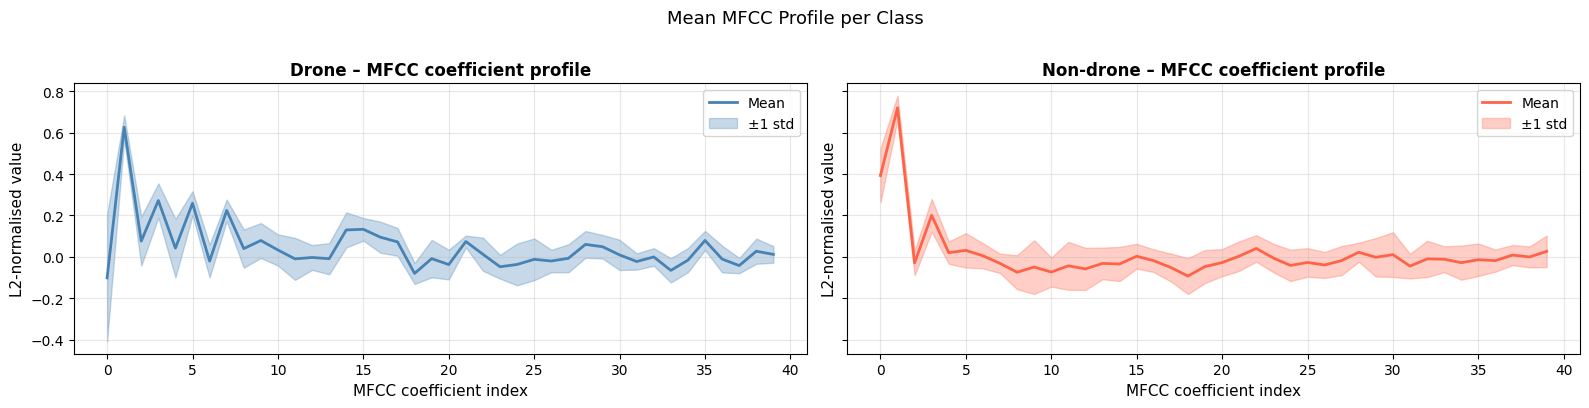

In [6]:
# ── Per-coefficient mean ± std across all frames ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

for ax, mfcc, title, color in zip(
        axes,
        [drone_mfcc, nondrone_mfcc],
        ["Drone", "Non-drone"],
        ["steelblue", "tomato"]):
    mean = mfcc.mean(axis=0)
    std  = mfcc.std(axis=0)
    x    = np.arange(N_MFCC)
    ax.plot(x, mean, color=color, linewidth=2, label="Mean")
    ax.fill_between(x, mean - std, mean + std, alpha=0.3, color=color, label="±1 std")
    ax.set_title(f"{title} – MFCC coefficient profile", fontsize=12, fontweight="bold")
    ax.set_xlabel("MFCC coefficient index", fontsize=11)
    ax.set_ylabel("L2-normalised value", fontsize=11)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Mean MFCC Profile per Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plots/mfcc_mean_profile.png", dpi=150, bbox_inches="tight")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'plots/mfcc_correlation.png'

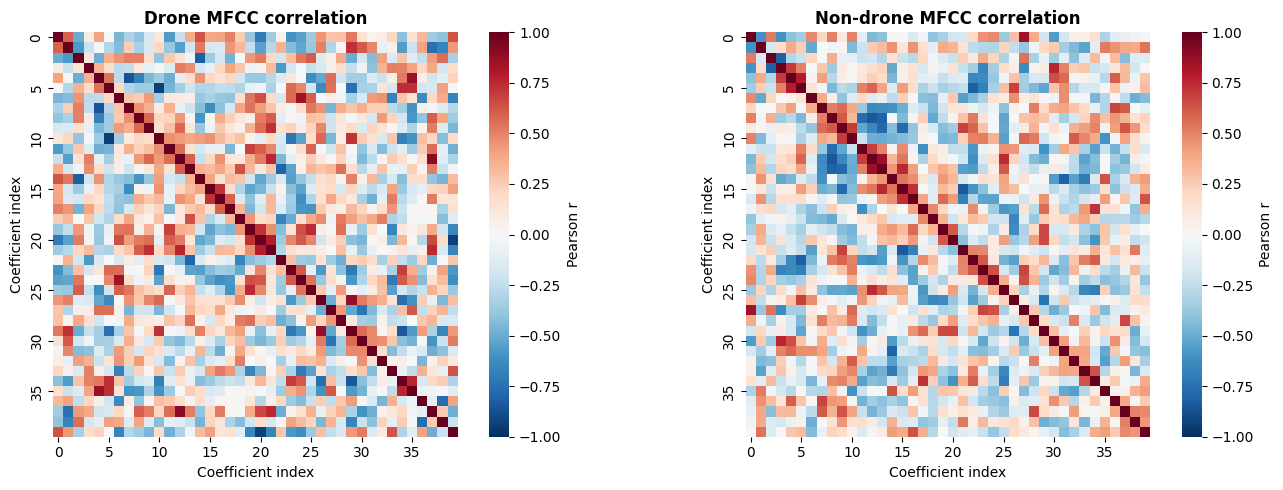

In [7]:
# ── Correlation heatmap of MFCC coefficients (drone vs non-drone) ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mfcc, title in zip(
        axes,
        [drone_mfcc, nondrone_mfcc],
        ["Drone MFCC correlation", "Non-drone MFCC correlation"]):
    corr = np.corrcoef(mfcc.T)
    sns.heatmap(corr, ax=ax, cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, square=True,
                xticklabels=5, yticklabels=5, cbar_kws={"label": "Pearson r"})
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Coefficient index")
    ax.set_ylabel("Coefficient index")

plt.tight_layout()
plt.savefig("plots/mfcc_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


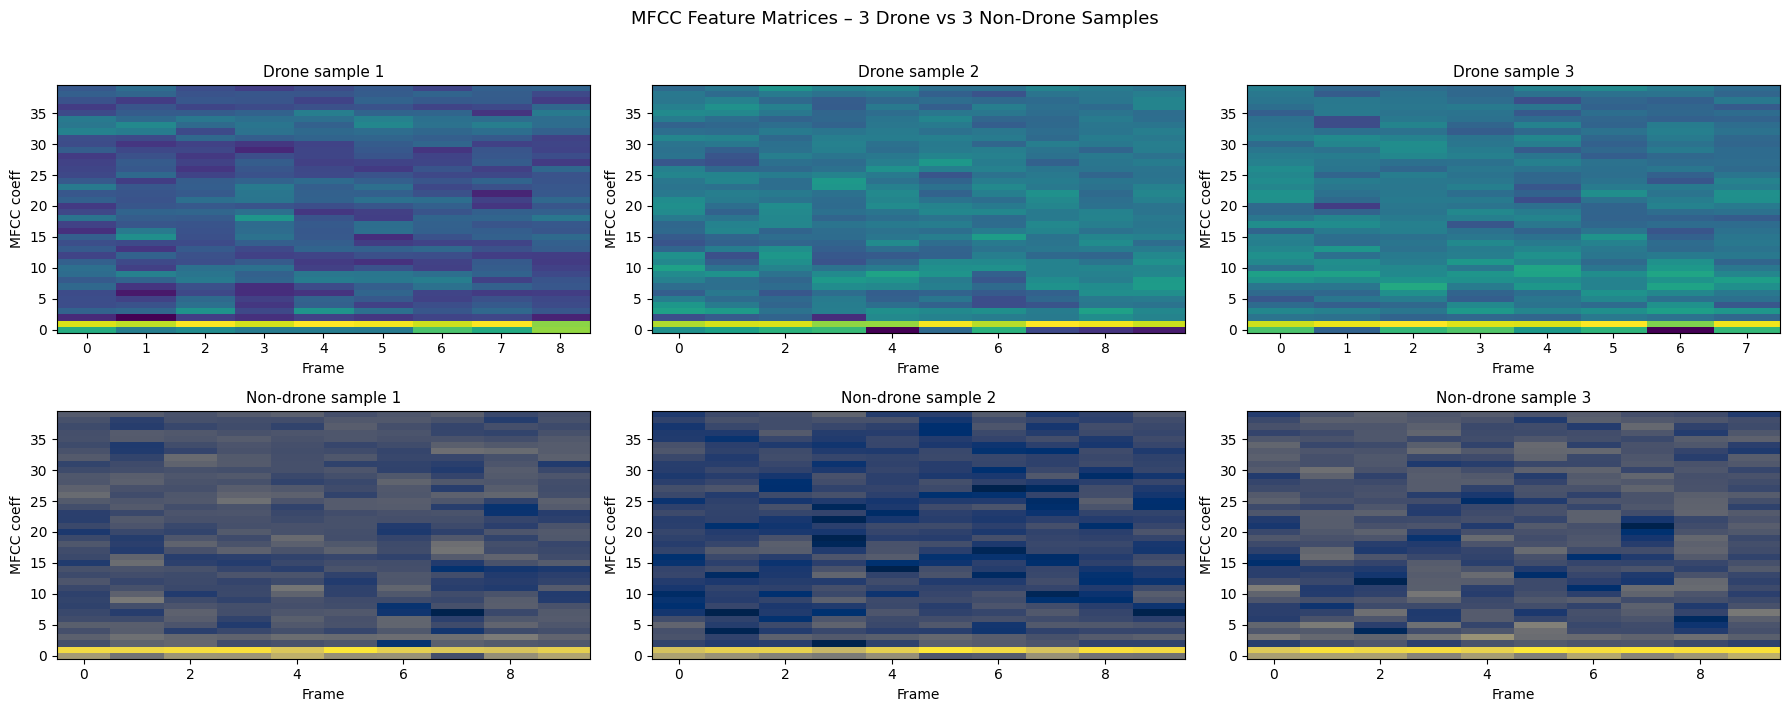

In [8]:
# ── MFCC spectrogram-style comparison across multiple samples ─────────────────
os.makedirs("plots", exist_ok=True)

drone_samples    = df[df["label"] == "drone"].sample(3, random_state=SEED)["file_path"].tolist()
nondrone_samples = df[df["label"] == "non_drone"].sample(3, random_state=SEED)["file_path"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 7))

for col, path in enumerate(drone_samples):
    mfcc = extract_mfcc_matrix(path)
    if mfcc is None: continue
    axes[0, col].imshow(mfcc.T, aspect="auto", origin="lower", cmap="viridis")
    axes[0, col].set_title(f"Drone sample {col+1}", fontsize=11)
    axes[0, col].set_xlabel("Frame")
    axes[0, col].set_ylabel("MFCC coeff")

for col, path in enumerate(nondrone_samples):
    mfcc = extract_mfcc_matrix(path)
    if mfcc is None: continue
    axes[1, col].imshow(mfcc.T, aspect="auto", origin="lower", cmap="cividis")
    axes[1, col].set_title(f"Non-drone sample {col+1}", fontsize=11)
    axes[1, col].set_xlabel("Frame")
    axes[1, col].set_ylabel("MFCC coeff")

plt.suptitle("MFCC Feature Matrices – 3 Drone vs 3 Non-Drone Samples", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plots/mfcc_sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()


## 2.4  Build feature dataset

In [9]:
os.makedirs("plots", exist_ok=True)

X_list, y_list = [], []
skipped = 0

label_map = {"drone": 1, "non_drone": 0, "unknown": -1}

for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
    label = label_map.get(row["label"], -1)
    if label == -1:
        skipped += 1
        continue

    mfcc_matrix = extract_mfcc_matrix(row["file_path"])
    if mfcc_matrix is None:
        skipped += 1
        continue

    windows = sliding_windows(mfcc_matrix)
    for w in windows:
        X_list.append(w)          # (10, 40)
        y_list.append(label)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print(f"\nFeature array shape : {X.shape}   (samples, frames, coefficients)")
print(f"Labels shape        : {y.shape}")
print(f"Skipped files       : {skipped}")
print(f"Class balance       : drone={y.sum()}, non-drone={(y==0).sum()}")


Extracting features: 100%|██████████| 2082/2082 [00:42<00:00, 49.22it/s]


Feature array shape : (1388, 10, 40)   (samples, frames, coefficients)
Labels shape        : (1388,)
Skipped files       : 0
Class balance       : drone=488, non-drone=900


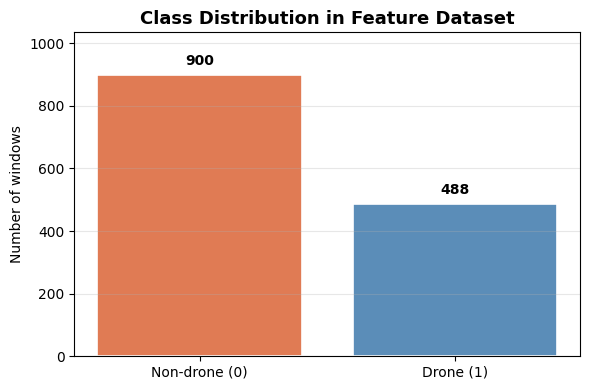

In [10]:
# ── Class balance bar chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
classes = ["Non-drone (0)", "Drone (1)"]
counts  = [(y == 0).sum(), (y == 1).sum()]
colors  = ["#e07b54", "#5b8db8"]
bars    = ax.bar(classes, counts, color=colors, edgecolor="white", linewidth=1.2)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{count:,}", ha="center", va="bottom", fontweight="bold")

ax.set_title("Class Distribution in Feature Dataset", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of windows")
ax.set_ylim(0, max(counts) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plots/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 2.5  Train / Validation / Test split and save

In [11]:
# Add channel dimension: (N, 10, 40) → (N, 10, 40, 1)
X = X[..., np.newaxis]
print(f"Final CNN input shape: {X.shape}")

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=SEED, stratify=y_train_val)

print(f"Train : {X_train.shape}  |  labels: {y_train.sum()} drone, {(y_train==0).sum()} non-drone")
print(f"Val   : {X_val.shape}    |  labels: {y_val.sum()} drone, {(y_val==0).sum()} non-drone")
print(f"Test  : {X_test.shape}   |  labels: {y_test.sum()} drone, {(y_test==0).sum()} non-drone")


Final CNN input shape: (1388, 10, 40, 1)
Train : (832, 10, 40, 1)  |  labels: 292 drone, 540 non-drone
Val   : (278, 10, 40, 1)    |  labels: 98 drone, 180 non-drone
Test  : (278, 10, 40, 1)   |  labels: 98 drone, 180 non-drone


In [12]:
np.save("X_train.npy", X_train)
np.save("X_val.npy",   X_val)
np.save("X_test.npy",  X_test)
np.save("y_train.npy", y_train)
np.save("y_val.npy",   y_val)
np.save("y_test.npy",  y_test)

print("Saved:")
for name in ["X_train","X_val","X_test","y_train","y_val","y_test"]:
    arr = np.load(f"{name}.npy")
    print(f"  {name}.npy  →  {arr.shape}  dtype={arr.dtype}")


Saved:
  X_train.npy  →  (832, 10, 40, 1)  dtype=float32
  X_val.npy  →  (278, 10, 40, 1)  dtype=float32
  X_test.npy  →  (278, 10, 40, 1)  dtype=float32
  y_train.npy  →  (832,)  dtype=int32
  y_val.npy  →  (278,)  dtype=int32
  y_test.npy  →  (278,)  dtype=int32


## 2.6  Summary

| File | Description |
|---|---|
| `X_train.npy` | Training features (N, 10, 40, 1) |
| `X_val.npy` | Validation features |
| `X_test.npy` | Test features |
| `y_*.npy` | Corresponding binary labels (1=drone, 0=non-drone) |
| `plots/` | All visualisations saved as PNG |